# 04b — Qualitative Analysis

**Actual qualitative scope** (discoveries after inspection):
- Q9: 5 words associated with data quality — stemming (RSLP) + frequency by position
- Q10: Requirements Engineering experience — open text (32 PT responses)
- Q12: importance justification — open text (12 responses)
- Q14: priority justification — open text (9 responses)
- Q15: trade-offs across characteristics — open text (31 responses)

**Procedure**:
1. Single-coder coding (this notebook = coder 1) — declared as a validity threat
2. Emergent categories (open coding) → axial coding into broad themes
3. Tabular codebook: category → subcategory → illustrative quotes → frequency
4. Q9 stemming with `nltk.RSLPStemmer` + analysis by position (1st word = top of mind)
5. Textual findings boxes

**Acknowledged limitation**: "classic" Grounded Theory requires 2+ coders and Cohen's κ. Here we have 1 coder → declared as a threat to construct validity. The published codebook in the replication package enables third-party re-coding.

In [1]:
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"

# Ensure NLTK resources
for resource in ["rslp", "stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource, quiet=True)

from nltk.stem import RSLPStemmer
from nltk.corpus import stopwords as nltk_stopwords

stemmer = RSLPStemmer()
STOPWORDS_PT = set(nltk_stopwords.words("portuguese"))
STOPWORDS_PT |= {"sim", "nao", "não", "ja", "já", "ainda", "talvez", "sempre", "nunca",
                  ".", "...", "…"}

df = U.load_anonymized()
words_long = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)} | tokens Q9={len(words_long)}")

N=41 | tokens Q9=204


## 1. Q9 — stemming and frequency by position

RSLP: lightweight Portuguese stemmer. Not full lemmatization but groups morphological variants ("precisão"/"preciso" → "precis"). After stemming, map each stem → most frequent canonical form for display.

In [2]:
def stem_pt(token) -> str:
    if not isinstance(token, str):
        return ""
    t = token.strip().lower()
    # Remove stray punctuation
    t = re.sub(r"[^\wáéíóúâêôãõç]", "", t)
    if not t or t in STOPWORDS_PT:
        return ""
    return stemmer.stem(t)

words_long["stem"] = words_long["word"].apply(stem_pt)
words_long = words_long[words_long["stem"] != ""].copy()

# Map stem → canonical form (most frequent word producing that stem)
stem_to_form = (words_long.groupby(["stem", "word"]).size()
                .reset_index(name="freq")
                .sort_values(["stem", "freq"], ascending=[True, False])
                .drop_duplicates("stem")
                .set_index("stem")["word"])
words_long["canonical"] = words_long["stem"].map(stem_to_form)
print(words_long.head(10))
print(f"\nTokens after stopwords: {len(words_long)}")
print(f"Unique stems: {words_long['stem'].nunique()}")

   position            word     stem       canonical
0         1        precisão   precis        precisão
1         1           fonte     font           fonte
2         1  confiabilidade    confi  confiabilidade
3         1           ruído     ruíd           ruído
4         1        precisão   precis        precisão
5         1    consistência  consist    consistência
6         1          treino    trein          treino
7         1   balanceamento  balance   balanceamento
8         1  confiabilidade    confi  confiabilidade
9         1       qualidade     qual       qualidade

Tokens after stopwords: 202
Unique stems: 130


In [3]:
# Overall frequency by canonical
freq_total = words_long["canonical"].value_counts().head(20)
print("=== Top-20 stemmed ===")
print(freq_total)

=== Top-20 stemmed ===
canonical
consistência       10
precisão            8
confiabilidade      8
relevância          7
completude          7
atualização         7
qualidade           4
quantidade          4
integração          4
volume              4
outliers            3
acurácia            3
balanceamento       2
corretude           2
limpeza             2
disponibilidade     2
diversidade         2
completeness        2
validade            2
distribution        2
Name: count, dtype: int64


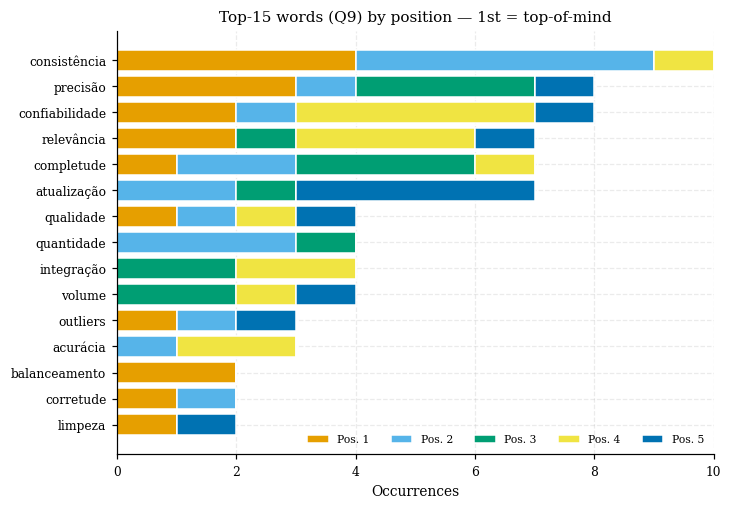

In [4]:
# Frequency by position: 1st word (top-of-mind) vs 5th word
fig, ax = plt.subplots(figsize=(7.0, 5.0))
top_overall = freq_total.head(15).index.tolist()
by_pos = (words_long[words_long["canonical"].isin(top_overall)]
          .groupby(["canonical", "position"]).size()
          .unstack(fill_value=0)
          .reindex(top_overall))
by_pos = by_pos.iloc[::-1]  # Reverse for horizontal bars
y = np.arange(len(by_pos))
bottom = np.zeros(len(by_pos))
colors = U.PALETTE_WONG[1:6]
for pos in [1, 2, 3, 4, 5]:
    if pos not in by_pos.columns:
        continue
    width = by_pos[pos].values
    ax.barh(y, width, left=bottom, color=colors[pos - 1],
            edgecolor="white", label=f"Pos. {pos}")
    bottom += width
ax.set_yticks(y)
ax.set_yticklabels(by_pos.index)
ax.set_xlabel("Occurrences")
ax.set_title("Top-15 words (Q9) by position — 1st = top-of-mind")
ax.legend(loc="lower right", frameon=False, ncol=5, fontsize=7)
U.save_fig(fig, "words_by_position")
plt.show()

In [5]:
# Top-3 of position 1 (most top-of-mind word)
first_word_top = (words_long[words_long["position"] == 1]["canonical"]
                  .value_counts().head(5))
print("Most frequent words in position 1 (top-of-mind):")
print(first_word_top)
print()
fifth_word_top = (words_long[words_long["position"] == 5]["canonical"]
                  .value_counts().head(5))
print("Most frequent words in position 5 (most distant):")
print(fifth_word_top)

Most frequent words in position 1 (top-of-mind):
canonical
consistência      4
precisão          3
confiabilidade    2
balanceamento     2
relevância        2
Name: count, dtype: int64

Most frequent words in position 5 (most distant):
canonical
atualização      4
viés             1
determinante     1
processamento    1
validação        1
Name: count, dtype: int64


## 2. Q10 — Requirements Engineering Experience

Manual open coding (coder 1: this notebook). 32 responses. Emergent categories:

In [6]:
# Manual coding based on prior reading of the 32 responses
# Each respondent can have MULTIPLE codes
Q10_CODES = {
    # respondent_id: (assigned codes, short illustrative quote)
    0: (["experiencia_positiva_geral"], "foi uma ótima experiência, embora complicada"),
    1: (["sem_experiencia"], "Não"),
    2: (["experiencia_inicial_projeto"], "primeiros passos quando começamos um projeto"),
    3: (["requisitos_para_modelo_ml_distintos", "colaboracao_com_qa", "alinhamento_stakeholders"],
        "levantei a necessidade de termos requisitos claros... para o modelo, para alinhar comportamento e performance às expectativas dos stakeholders"),
    4: (["experiencia_completa_ciclo"], "todas as fases do ciclo de um projeto em Ciência de Dados"),
    5: (["sem_experiencia"], "Não"),
    6: (["sem_experiencia"], "Não"),
    7: (["experiencia_diversificada"], "projetos de diversas aplicações, metodologias e tecnologias"),
    8: (["documentacao_formal"], "Registro formal dos requisitos em documentos detalhados, especificações funcionais e não funcionais, casos de uso"),
    9: (["experiencia_apenas_academica"], "apenas em trabalhos acadêmicos"),
    10: (["elicitacao_estruturada"], "elicitação de requisitos, análise de documentos e entrevistas semiestruturadas"),
    11: (["sem_experiencia"], "Nunca participei"),
    12: (["experiencia_apenas_academica", "reconhecimento_importancia"],
         "em disciplinas na universidade... extrema importância porque era o que nos guiava no desenvolvimento"),
    13: (["papel_periferico", "foco_documentacao_codigo"],
         "mais voltada para a documentação do código e na criação de diagramas referentes a pipelines"),
    14: (["foco_dependencias"], "Somente documentação de dependências e bibliotecas"),
    15: (["refinamento_iterativo", "discussao_complexidade"],
         "refinamento de requisitos, discutimos com a equipe a complexidade e capacidade do time"),
    16: (["requisitos_processo_negocio"],
         "escopo analise e desenho dos processos de negócio implicados na mudança"),
    17: (["sem_experiencia"], "Não"),
    18: (["experiencia_minima"], "Sim"),
    19: (["prazos_curtos_limitam", "foco_coleta", "variabilidade_porte_empresa"],
         "prazos sempre foram extremamente curtos para realizar um estudo aprofundado... empresas com menor capital tendem a ser mais exploratórias e desorganizadas"),
    20: (["sem_experiencia"], "Nunca participei de atividades de engenharia de requisitos"),
    21: (["resposta_vazia"], "…"),
    22: (["foco_funcionais_apis"], "requisitos funcionais como integrações utilizando API e cadastros de usuarios"),
    23: (["dependencia_especialistas_dominio", "trabalho_demorado"],
         "trabalhoso e demorado, pois é preciso ter o entendimento do contexto de negócio... regras estão na cabeça do usuário"),
    24: (["sem_experiencia"], "Não"),
    25: (["experiencia_completa_ciclo", "avaliacao_viabilidade"],
         "descrever e avaliar a viabilidade na fase de concepção"),
    26: (["reconhecimento_importancia", "prevencao_atritos"],
         "etapa crucial para a definição de um bom escopo, evitando atritos entre a equipe e o cliente"),
    27: (["elicitacao_informal", "sem_documento_formal"],
         "de maneira informal com os membros relevantes do time em uma reunião, sem geração de um documento formalizando tudo"),
    28: (["jornadas_usuario", "foco_publico_alvo"],
         "jornadas de usuário conversando com clientes para entender como um produto de IA poderia ajudar no cotidiano"),
    29: (["refinamento_iterativo", "levantamento_cenarios", "requisitos_funcionais_e_nfr"],
         "reunião com o cliente onde ele faz o levantamento dos cenários... criação das Histórias, Cenários e Requisitos Funcionais e Não Funcionais"),
    30: (["experiencia_completa_ciclo", "analise_sistemas_anteriores", "prototipos"],
         "análise de sistemas anteriores e documentações existentes, além de entrevistas e confecção de protótipos"),
    31: (["sem_experiencia"], "Não"),
}

Q10_CATEGORIES = {
    "sem_experiencia": "No RE experience",
    "experiencia_apenas_academica": "Academic-only experience",
    "experiencia_completa_ciclo": "Experience across all phases",
    "experiencia_diversificada": "Experience in diverse projects",
    "experiencia_minima": "Minimal experience / no details",
    "experiencia_inicial_projeto": "RE as the first project steps",
    "experiencia_positiva_geral": "Generic positive experience",
    "requisitos_para_modelo_ml_distintos": "ML-specific model requirements",
    "colaboracao_com_qa": "Collaboration with QA",
    "alinhamento_stakeholders": "Stakeholder alignment",
    "documentacao_formal": "Formal documentation",
    "sem_documento_formal": "Informal/missing documentation",
    "elicitacao_estruturada": "Structured elicitation techniques",
    "elicitacao_informal": "Informal elicitation (meetings)",
    "refinamento_iterativo": "Iterative refinement with client",
    "levantamento_cenarios": "Scenario/story gathering",
    "requisitos_funcionais_e_nfr": "Functional and non-functional requirements",
    "requisitos_processo_negocio": "Business-process requirements",
    "foco_documentacao_codigo": "Focus on code documentation",
    "foco_dependencias": "Focus on dependencies/libraries",
    "foco_funcionais_apis": "Focus on functional (APIs/forms)",
    "foco_publico_alvo": "Focus on target audience (journeys)",
    "foco_coleta": "Focus on data collection",
    "papel_periferico": "Peripheral role in RE",
    "reconhecimento_importancia": "Acknowledged importance",
    "prazos_curtos_limitam": "Short deadlines limit depth",
    "trabalho_demorado": "Tedious and time-consuming process",
    "variabilidade_porte_empresa": "Variability with company size",
    "dependencia_especialistas_dominio": "Reliance on domain experts",
    "prevencao_atritos": "RE as friction prevention",
    "jornadas_usuario": "User journeys",
    "avaliacao_viabilidade": "Feasibility assessment",
    "prototipos": "Use of prototypes",
    "analise_sistemas_anteriores": "Analysis of legacy systems",
    "discussao_complexidade": "Discussion of complexity/capacity",
    "resposta_vazia": "Empty / uncodeable response",
}

q10_freq = Counter()
for codes, _ in Q10_CODES.values():
    for c in codes:
        q10_freq[c] += 1
q10_table = pd.DataFrame([
    {"code": c, "label": Q10_CATEGORIES[c], "n": n}
    for c, n in sorted(q10_freq.items(), key=lambda x: -x[1])
])
print("=== Q10 — code frequencies ===")
print(q10_table.to_string(index=False))

=== Q10 — code frequencies ===
                               code                                      label  n
                    sem_experiencia                           No RE experience  8
         experiencia_completa_ciclo               Experience across all phases  3
       experiencia_apenas_academica                   Academic-only experience  2
         reconhecimento_importancia                    Acknowledged importance  2
              refinamento_iterativo           Iterative refinement with client  2
         experiencia_positiva_geral                Generic positive experience  1
        experiencia_inicial_projeto              RE as the first project steps  1
requisitos_para_modelo_ml_distintos             ML-specific model requirements  1
                 colaboracao_com_qa                      Collaboration with QA  1
           alinhamento_stakeholders                      Stakeholder alignment  1
          experiencia_diversificada             Experience in diver

## 3. Q12 — Importance justification (12 responses)

In [7]:
Q12_CODES = {
    7: (["garbage_in_garbage_out", "impacto_modelo"], "se os dados forem uma bagunça, o modelo só vai cuspir lixo sofisticado"),
    11: (["todas_importantes", "distincao_critico_vs_corrigivel", "qualidade_intrinseca_inegociavel"],
         "separação foi mais pensando em algo que podemos fazer/corrigir em um segundo momento ou algo que é fundamental de ser pensado desde o início... qualidade dos dados são coisas inegociáveis"),
    12: (["todas_importantes", "impacto_pesquisa_e_mercado", "viabilizar_novas_tecnicas"],
         "todas as características são de extrema importância... dados de má qualidade são um grande problema na área e dificultam o desenvolvimento de novas técnicas"),
    14: (["reflexo_real", "interpretabilidade_humana", "confiabilidade_resultado"],
         "refletir com eficiência e sem muitos erros... compreensíveis até certo ponto para os humanos... confiáveis em termos de garantir que a informação final não esteja errada"),
    16: (["contexto_dependente"], "Dependem do escopo do projeto e o do objetivo do aprendizado"),
    17: (["qualidade_pipeline", "importancia_relacional"],
         "se isso não acontecer, todo o resultado proveniente do seu pipeline de ML pode estar comprometido... a rastreabilidade é super importante para a execução de testes com dados mais antigos, debug ou rollback"),
    19: (["diferenca_importancia_vs_necessidade", "prazo_aperta_necessidade"],
         "diferença entre algo ser importante e ser necessário... a importância é limitada pela urgência dos prazos"),
    25: (["relevante_mas_nao_impeditivo"], "critérios relevantes, mas que não promovem impedimentos"),
    26: (["impacto_metricas", "reflexo_real"],
         "dados mais atuais, precisos e coerentes com o cenário real tendem a apresentar resultados melhores nas métricas"),
    29: (["prevencao_falha_silenciosa", "impacto_modelo"],
         "a negligência a esses pontos... podem levar a resultados que parecem promissores, mas que em uma análise mais profunda pode estar relacionada a dados que não são devidamente limpos"),
    30: (["qualidade_pipeline", "confiabilidade_resultado"],
         "se o dado não tiver a maioria desses atributos, qualquer resultado de qualquer modelo de ML não será confiável"),
    31: (["confiabilidade_resultado", "importancia_producao"],
         "dados devem ser confiáveis e fazer sentido, é fundamental para que o sistema funcione corretamente quando colocado em produção"),
}

Q12_CATEGORIES = {
    "garbage_in_garbage_out": "Garbage-in/garbage-out principle",
    "todas_importantes": "All characteristics are important",
    "contexto_dependente": "Importance depends on context/objective",
    "impacto_modelo": "Direct impact on the model",
    "qualidade_pipeline": "Compromises the entire pipeline",
    "reflexo_real": "Reflecting real-world scenarios",
    "interpretabilidade_humana": "Interpretability for humans",
    "confiabilidade_resultado": "Reliability of the final result",
    "importancia_producao": "Importance for production systems",
    "diferenca_importancia_vs_necessidade": "Important ≠ required in every project",
    "prazo_aperta_necessidade": "Deadlines restrict what becomes necessary",
    "distincao_critico_vs_corrigivel": "Distinction between critical and later-fixable",
    "qualidade_intrinseca_inegociavel": "Intrinsic quality is non-negotiable",
    "impacto_pesquisa_e_mercado": "Impact on research and industry",
    "viabilizar_novas_tecnicas": "Enabling development of new techniques",
    "importancia_relacional": "Relational importance between characteristics",
    "relevante_mas_nao_impeditivo": "Relevant but not blocking",
    "impacto_metricas": "Impact on accuracy metrics",
    "prevencao_falha_silenciosa": "Prevention of silent failures",
}
q12_freq = Counter()
for codes, _ in Q12_CODES.values():
    for c in codes:
        q12_freq[c] += 1
q12_table = pd.DataFrame([
    {"code": c, "label": Q12_CATEGORIES[c], "n": n}
    for c, n in sorted(q12_freq.items(), key=lambda x: -x[1])
])
print(q12_table.to_string(index=False))

                                code                                          label  n
            confiabilidade_resultado                Reliability of the final result  3
                      impacto_modelo                     Direct impact on the model  2
                   todas_importantes              All characteristics are important  2
                        reflexo_real                Reflecting real-world scenarios  2
                  qualidade_pipeline                Compromises the entire pipeline  2
              garbage_in_garbage_out               Garbage-in/garbage-out principle  1
     distincao_critico_vs_corrigivel Distinction between critical and later-fixable  1
    qualidade_intrinseca_inegociavel            Intrinsic quality is non-negotiable  1
          impacto_pesquisa_e_mercado                Impact on research and industry  1
           viabilizar_novas_tecnicas         Enabling development of new techniques  1
           interpretabilidade_humana       

## 4. Q14 — Priority justification (9 responses)

In [8]:
Q14_CODES = {
    12: (["reprodutibilidade", "acelerar_desenvolvimento"],
         "essenciais para reproduzir técnicas, seja para fins de pesquisa ou mercado... influencia também em um desenvolvimento mais rápido"),
    15: (["reflexo_dominio"], "garantir que os dados realmente refletem a área de conhecimento"),
    19: (["contexto_dependente", "neutro_por_indecisao"],
         "vai depender demais do projeto em questão, então prefiro colocar neutro"),
    20: (["contexto_dependente", "sensibilidade_dominio", "requisitos_temporais"],
         "todos requisitos são essenciais dependendo do contexto... a conformidade depende do quão sensíveis forem os dados... a eficiência vai depender se o sistema é utilizado em tempo real"),
    25: (["relevante_nao_funcional"], "prioritário, mas não impactam requisitos funcionais"),
    26: (["reflexo_real", "impacto_metricas"],
         "consistência e completude indicarão o quanto os dados representam os cenários de um ambiente real"),
    29: (["prevencao_overfitting_underfitting", "prioridade_inicio_projeto"],
         "se não considerados no início do projeto, podem levar a modelos com overfitting ou underfitting"),
    30: (["qualidade_imprescindivel", "sem_meio_termo"],
         "todo dado utilizado na execução de algoritmos de ML deve ter qualidade, senão todo resultado será duvidoso e não confiável. Não existe meio termo"),
    31: (["confiabilidade_resultado", "importancia_producao", "tomada_de_decisao"],
         "para tomar decisões com base nesses dados, a informação deve ser precisa e consistente"),
}

Q14_CATEGORIES = {
    "reprodutibilidade": "Technical reproducibility",
    "acelerar_desenvolvimento": "Accelerated development",
    "reflexo_dominio": "Reflecting the knowledge domain",
    "contexto_dependente": "Priority depends on context",
    "neutro_por_indecisao": "Neutral due to indecision over variability",
    "sensibilidade_dominio": "Domain sensitivity (healthcare, banking)",
    "requisitos_temporais": "Temporal requirements (real-time)",
    "relevante_nao_funcional": "Relevant but non-functional",
    "reflexo_real": "Reflects real scenarios",
    "impacto_metricas": "Impact on accuracy metrics",
    "prevencao_overfitting_underfitting": "Prevention of overfitting/underfitting",
    "prioridade_inicio_projeto": "Prioritization from project start",
    "qualidade_imprescindivel": "Indispensable quality, no middle ground",
    "sem_meio_termo": "No middle ground between high and low quality",
    "confiabilidade_resultado": "Result reliability",
    "importancia_producao": "Importance for production",
    "tomada_de_decisao": "Decision making",
}
q14_freq = Counter()
for codes, _ in Q14_CODES.values():
    for c in codes:
        q14_freq[c] += 1
q14_table = pd.DataFrame([
    {"code": c, "label": Q14_CATEGORIES[c], "n": n}
    for c, n in sorted(q14_freq.items(), key=lambda x: -x[1])
])
print(q14_table.to_string(index=False))

                              code                                         label  n
               contexto_dependente                   Priority depends on context  2
                 reprodutibilidade                     Technical reproducibility  1
          acelerar_desenvolvimento                       Accelerated development  1
                   reflexo_dominio               Reflecting the knowledge domain  1
              neutro_por_indecisao    Neutral due to indecision over variability  1
             sensibilidade_dominio      Domain sensitivity (healthcare, banking)  1
              requisitos_temporais             Temporal requirements (real-time)  1
           relevante_nao_funcional                   Relevant but non-functional  1
                      reflexo_real                       Reflects real scenarios  1
                  impacto_metricas                    Impact on accuracy metrics  1
prevencao_overfitting_underfitting        Prevention of overfitting/underfit

## 5. Q15 — Trade-offs across characteristics (31 responses)

In [9]:
# Central theme: context dependence. Coded by sub-themes
Q15_CODES = {
    0: (["contexto_dependente", "interpretabilidade_modelos_criticos", "trade_off_precisao_eficiencia", "hibridismo_regras_e_ml"],
        "para modelos críticos, como risco de crédito, priorizamos interpretabilidade... combinamos regras simples com machine learning sofisticado"),
    1: (["hierarquia_precisao_compreensibilidade_eficiencia"], "prioridade na precisão, seguido de compreensibilidade e eficiência"),
    2: (["contexto_dependente_aplicacao"], "depende de como nossa aplicação precisará responder ao usuário"),
    4: (["contexto_dependente"], "decisões estratégicas que dependem do contexto do projeto"),
    5: (["selecao_features", "reducao_dimensionalidade", "limpeza_dados", "trade_off_simplicidade_complexidade", "monitoramento_continuo"],
        "seleção de features, redução de dimensionalidade e limpeza de dados... modelos mais simples preferíveis quando explicabilidade é essencial"),
    6: (["resposta_minima"], "."),
    7: (["trade_off_complexidade_praticidade"], "o segredo é encontrar o ponto ideal entre complexidade e praticidade"),
    8: (["contexto_dependente"], "cada decisão deve ser baseada no contexto específico do projeto"),
    9: (["sem_resposta_substantiva"], "Não sei descrever"),
    10: (["valor_eficiencia"], "essenciais para a entrega de valor e resultados eficientes"),
    11: (["sequenciamento_qualidade_legibilidade_pipeline"],
         "foco inicialmente na qualidade dos dados em termos de serem precisos, completos e atuais. Em segundo momento... o usuário do sistema. Finalmente... otimizar o processamento"),
    12: (["contexto_dominio_medico", "trade_off_consistencia_credibilidade", "documentacao_processo"],
         "trabalho com imagens médicas, conciliação entre falta de consistência e atualidade com compreensibilidade, disponibilidade, acessibilidade e principalmente credibilidade"),
    13: (["hierarquia_precisao_compreensibilidade_eficiencia", "trade_off_robustez_capacidade_computacional"],
         "sempre venho dando mais ênfase na precisão dos dados, seguido da compreensibilidade e eficiência... escolha entre dois datasets, um mais robusto que iria demandar muito mais poder computacional"),
    14: (["contexto_visao_computacional", "trade_off_volume_eficiencia"],
         "em visão computacional, dados precisam ser direta e com exatidão... a depender da quantidade, não pode ser muito grande"),
    15: (["trade_off_completude_confiabilidade"], "as vezes os dados podem não estar completos, mas a confiabilidade pode ser mais alta"),
    16: (["contexto_dependente"], "varia segundo o objetivo do aprendizado, fontes e métricas dos rótulos"),
    17: (["problema_orientado", "trade_off_consistencia_credibilidade"],
         "sempre entender o problema a ser solucionado para dar importância maior para uma característica em detrimento de outras"),
    18: (["impacto_qualidade_resposta_usuario", "custo_retrabalho"],
         "quando os dados não são consistentes ou incompletos a inferência e resultado final ao cliente pode ser confuso... gastos de infra em todo o fluxo"),
    19: (["resultado_orientado", "contexto_dependente"],
         "primeiro o resultado e depois avaliar como ele poderia ser melhorado, revisitando essas características"),
    20: (["contexto_dominio_medico", "federated_learning", "conformidade_local"],
         "projeto que trata anamneses de hospitais. Para manter conformidade, abordamos soluções de aprendizado de máquina federado"),
    21: (["papel_ferramentas_plataforma"], "boas ferramentas de mercado como o databricks ajuda o cientista a focar na solução"),
    22: (["praticas_padronizadas_pilares"], "boas práticas para cada pilar como: disponibilidade, segurança, confiabilidade"),
    23: (["definicao_qualidade_geral"], "características que definem a qualidade do dado para ser utilizado"),
    24: (["exploracao_amostra", "limpeza_dados", "contexto_dependente"],
         "depende do problema e do conjunto de dados disponível... padronização, remoção de ruídos"),
    25: (["contexto_dominio_medico", "trade_off_resolucao_custo_computacional"],
         "sistemas de análises médicas... imagens clínicas geralmente têm alta resolução pois demandam confiabilidade... grandes volumes impactam eficiência computacional"),
    26: (["contexto_dependente_tempo_real", "flexibilidade_tempo_resposta"],
         "se há requisitos de tempo real ou não, se o tempo de espera para a resposta é sensível, pode levar a maior flexibilidade quanto a taxas de acerto"),
    27: (["caracteristicas_essenciais_universais", "caracteristicas_dependentes_aplicacao", "requisitos_para_pesquisa_vs_producao", "importancia_para_produto_vs_dados"],
         "Precisão, Completude, Consistência, Credibilidade essenciais não importa a situação... Atualidade prioritária para meteorologia, serviços críticos, bancários"),
    28: (["contexto_dominio_biometrico", "limpeza_complexa", "validacao_humana"],
         "sistemas biométricos... etapas de limpezas bem complexas priorizando eficiência e precisão... validação humana após a execução do modelo"),
    29: (["feature_selection", "tuning_iterativo"],
         "treinamentos com diferentes configurações e tipos de dados... Feature Selection pode ser utilizada"),
    30: (["contexto_dominio_critico", "qualidade_imprescindivel_em_critico"],
         "saúde, vida e morte deve considerar apenas dados de boa qualidade... qualquer dado não confiável deve ser eliminado"),
    31: (["resposta_minima"], "."),
}

Q15_CATEGORIES = {
    "contexto_dependente": "Balance depends on project context",
    "contexto_dependente_aplicacao": "Depends on the application/user",
    "contexto_dependente_tempo_real": "Depends on temporal requirements",
    "contexto_dominio_medico": "Medical domain has its own constraints",
    "documentacao_processo": "Documentation of the decision process",
    "contexto_dominio_biometrico": "Biometric domain",
    "contexto_dominio_critico": "Critical domains (healthcare/life)",
    "contexto_visao_computacional": "Computer vision domain",
    "hierarquia_precisao_compreensibilidade_eficiencia": "Explicit hierarchy: precision > understandability > efficiency",
    "trade_off_precisao_eficiencia": "Trade-off precision × efficiency",
    "trade_off_complexidade_praticidade": "Trade-off complexity × practicality",
    "trade_off_simplicidade_complexidade": "Trade-off simplicity × model complexity",
    "trade_off_consistencia_credibilidade": "Trade-off across sources (consistency × credibility)",
    "trade_off_volume_eficiencia": "Trade-off volume × efficiency",
    "trade_off_completude_confiabilidade": "Trade-off completeness × reliability",
    "trade_off_resolucao_custo_computacional": "Trade-off resolution × compute cost",
    "trade_off_robustez_capacidade_computacional": "Trade-off dataset robustness × compute capacity",
    "interpretabilidade_modelos_criticos": "Interpretable models for critical decisions",
    "hibridismo_regras_e_ml": "Hybrid rules + ML",
    "selecao_features": "Feature selection",
    "feature_selection": "Iterative feature selection",
    "reducao_dimensionalidade": "Dimensionality reduction",
    "limpeza_dados": "Cleaning/noise removal",
    "limpeza_complexa": "Complex pre-modeling cleaning",
    "monitoramento_continuo": "Continuous performance monitoring",
    "sequenciamento_qualidade_legibilidade_pipeline": "Sequencing: quality → readability → optimization",
    "valor_eficiencia": "Efficiency as value delivery",
    "problema_orientado": "Problem-oriented decision",
    "resultado_orientado": "Outcome-oriented decision",
    "impacto_qualidade_resposta_usuario": "Quality affects user-facing output",
    "custo_retrabalho": "Rework/infra cost",
    "federated_learning": "Federated learning for compliance",
    "conformidade_local": "Compliance requires local processing",
    "papel_ferramentas_plataforma": "Off-the-shelf platforms/tools",
    "praticas_padronizadas_pilares": "Standardized practices across pillars",
    "caracteristicas_essenciais_universais": "Essential-universal characteristic subset",
    "caracteristicas_dependentes_aplicacao": "Application-dependent subset",
    "requisitos_para_pesquisa_vs_producao": "Requirements differ in research vs production",
    "importancia_para_produto_vs_dados": "Greater importance in product than in raw data",
    "qualidade_imprescindivel_em_critico": "Indispensable quality in critical domains",
    "validacao_humana": "Human post-model validation",
    "definicao_qualidade_geral": "Generic quality definition",
    "flexibilidade_tempo_resposta": "Flexibility based on response time",
    "exploracao_amostra": "Sample exploration before deciding",
    "tuning_iterativo": "Iterative tuning with different configurations",
    "resposta_minima": "Empty/minimal response (\".\")",
    "sem_resposta_substantiva": "No substantive answer (\"don't know\")",
}

q15_freq = Counter()
for codes, _ in Q15_CODES.values():
    for c in codes:
        q15_freq[c] += 1
q15_table = pd.DataFrame([
    {"code": c, "label": Q15_CATEGORIES[c], "n": n}
    for c, n in sorted(q15_freq.items(), key=lambda x: -x[1])
])
print(q15_table.head(15).to_string(index=False))

                                             code                                                          label  n
                              contexto_dependente                             Balance depends on project context  6
                          contexto_dominio_medico                         Medical domain has its own constraints  3
hierarquia_precisao_compreensibilidade_eficiencia Explicit hierarchy: precision > understandability > efficiency  2
                                    limpeza_dados                                         Cleaning/noise removal  2
                                  resposta_minima                                   Empty/minimal response (".")  2
             trade_off_consistencia_credibilidade           Trade-off across sources (consistency × credibility)  2
              interpretabilidade_modelos_criticos                    Interpretable models for critical decisions  1
                    trade_off_precisao_eficiencia                       

## 6. Axial coding — broad categories

Group open codes into themes:
- **T1 Contextualism**: importance/priority depends on domain, application, and temporal requirements
- **T2 Garbage-in-garbage-out**: poor quality compromises pipeline and results (silent-failure risk)
- **T3 Explicit trade-offs**: precision × efficiency, completeness × reliability, resolution × compute cost
- **T4 Quality hierarchy**: "essential-universal" subset + "context-dependent" subset
- **T5 Practices/Tools**: feature selection, cleaning, monitoring, platforms
- **T6 RE → ML gap**: limited/informal experience; missing documentation in half the cases; focus on functional reqs; ML model "forgotten" by traditional RE

In [10]:
AXIAL = {
    "T1_Contextualism": [
        "contexto_dependente", "contexto_dependente_aplicacao", "contexto_dependente_tempo_real",
        "contexto_dominio_medico", "contexto_dominio_biometrico", "contexto_dominio_critico",
        "contexto_visao_computacional", "sensibilidade_dominio", "requisitos_temporais",
        "variabilidade_porte_empresa",
    ],
    "T2_Garbage_in_out": [
        "garbage_in_garbage_out", "impacto_modelo", "qualidade_pipeline", "prevencao_falha_silenciosa",
        "prevencao_overfitting_underfitting", "qualidade_imprescindivel", "qualidade_imprescindivel_em_critico",
        "sem_meio_termo", "impacto_qualidade_resposta_usuario", "custo_retrabalho",
    ],
    "T3_Trade_offs": [
        "trade_off_precisao_eficiencia", "trade_off_complexidade_praticidade",
        "trade_off_simplicidade_complexidade", "trade_off_consistencia_credibilidade",
        "trade_off_volume_eficiencia", "trade_off_completude_confiabilidade",
        "trade_off_resolucao_custo_computacional", "trade_off_robustez_capacidade_computacional",
    ],
    "T4_Quality_hierarchy": [
        "hierarquia_precisao_compreensibilidade_eficiencia", "sequenciamento_qualidade_legibilidade_pipeline",
        "caracteristicas_essenciais_universais", "caracteristicas_dependentes_aplicacao",
        "importancia_para_produto_vs_dados", "requisitos_para_pesquisa_vs_producao",
        "todas_importantes", "distincao_critico_vs_corrigivel", "qualidade_intrinseca_inegociavel",
    ],
    "T5_Practices_Tools": [
        "selecao_features", "feature_selection", "reducao_dimensionalidade", "limpeza_dados",
        "limpeza_complexa", "monitoramento_continuo", "papel_ferramentas_plataforma",
        "praticas_padronizadas_pilares", "validacao_humana", "federated_learning",
        "hibridismo_regras_e_ml", "interpretabilidade_modelos_criticos", "tuning_iterativo",
        "exploracao_amostra",
    ],
    "T6_RE_ML_gap": [
        "sem_experiencia", "experiencia_apenas_academica", "experiencia_minima",
        "sem_documento_formal", "elicitacao_informal", "papel_periferico", "foco_dependencias",
        "foco_documentacao_codigo", "foco_funcionais_apis", "requisitos_para_modelo_ml_distintos",
        "prazos_curtos_limitam", "trabalho_demorado", "dependencia_especialistas_dominio",
        "diferenca_importancia_vs_necessidade", "prazo_aperta_necessidade",
    ],
}

all_codes_freq = Counter()
for q_codes in [Q10_CODES, Q12_CODES, Q14_CODES, Q15_CODES]:
    respondents_per_code = {}
    for rid, (codes, _) in q_codes.items():
        for c in codes:
            respondents_per_code.setdefault(c, set()).add(rid)
    for c, rs in respondents_per_code.items():
        all_codes_freq[c] += len(rs)

axial_table_rows = []
for theme, codes in AXIAL.items():
    n_total = 0
    for c in codes:
        n_total += all_codes_freq.get(c, 0)
    axial_table_rows.append({"theme": theme, "n_references": n_total, "codes": len(codes)})
axial_table = pd.DataFrame(axial_table_rows).sort_values("n_references", ascending=False)
print(axial_table.to_string(index=False))

               theme  n_references  codes
        T6_RE_ML_gap            23     15
    T1_Contextualism            20     10
  T5_Practices_Tools            15     14
   T2_Garbage_in_out            12     10
T4_Quality_hierarchy            11      9
       T3_Trade_offs             9      8


## 7. Persistence: tabular codebook + coded data

In [11]:
# Unified codebook (codes × theme × frequency × example)
ALL_CATEGORIES = {**Q10_CATEGORIES, **Q12_CATEGORIES, **Q14_CATEGORIES, **Q15_CATEGORIES}
code_to_theme = {}
for theme, codes in AXIAL.items():
    for c in codes:
        code_to_theme[c] = theme

# Pick example (first quote found per code)
code_to_quote = {}
for q_codes in [Q10_CODES, Q12_CODES, Q14_CODES, Q15_CODES]:
    for rid, (codes, quote) in q_codes.items():
        for c in codes:
            code_to_quote.setdefault(c, (rid, quote))

codebook_rows = []
for c, label in ALL_CATEGORIES.items():
    rid, quote = code_to_quote.get(c, (None, ""))
    codebook_rows.append({
        "code": c,
        "label": label,
        "theme": code_to_theme.get(c, "no_theme"),
        "n_references": all_codes_freq.get(c, 0),
        "example_respondent": f"P{rid:02d}" if rid is not None else "",
        "example_quote": quote,
    })
codebook = pd.DataFrame(codebook_rows).sort_values(["theme", "n_references"], ascending=[True, False])
codebook.to_csv(U.DATA_CODEBOOK / "coding_scheme.csv", index=False)
print(f"[saved] codebook → {len(codebook)} codes")

# Codings per respondent (long): respondent_id × question × code
coded_rows = []
for q_name, q_codes in [("Q10", Q10_CODES), ("Q12", Q12_CODES), ("Q14", Q14_CODES), ("Q15", Q15_CODES)]:
    for rid, (codes, quote) in q_codes.items():
        for c in codes:
            coded_rows.append({"respondent_id": rid, "question": q_name,
                                "code": c, "theme": code_to_theme.get(c, ""),
                                "quote": quote})
coded_df = pd.DataFrame(coded_rows)
coded_df.to_csv(U.DATA_CODEBOOK / "coded_responses.csv", index=False)
print(f"[saved] coded_responses → {len(coded_df)} (respondent, code) pairs")

[saved] codebook → 113 codes
[saved] coded_responses → 149 (respondent, code) pairs


## 8. Findings boxes — plug-and-play text

In [12]:
# % of respondents touching each theme
respondents_per_theme = {}
for q_codes in [Q10_CODES, Q12_CODES, Q14_CODES, Q15_CODES]:
    for rid, (codes, _) in q_codes.items():
        for c in codes:
            t = code_to_theme.get(c)
            if t:
                respondents_per_theme.setdefault(t, set()).add(rid)
for t, rs in respondents_per_theme.items():
    print(f"  {t}: {len(rs)}/{len(df)} ({len(rs)/len(df)*100:.0f}%) respondents")

  T6_RE_ML_gap: 18/41 (44%) respondents
  T1_Contextualism: 14/41 (34%) respondents
  T2_Garbage_in_out: 5/41 (12%) respondents
  T4_Quality_hierarchy: 5/41 (12%) respondents
  T5_Practices_Tools: 8/41 (20%) respondents
  T3_Trade_offs: 9/41 (22%) respondents


In [13]:
# RE → ML gap: count respondents with limited/zero RE experience
no_re = sum(1 for codes, _ in Q10_CODES.values() if any(c in {"sem_experiencia", "experiencia_apenas_academica", "experiencia_minima"} for c in codes))
informal_re = sum(1 for codes, _ in Q10_CODES.values() if any(c in {"sem_documento_formal", "elicitacao_informal", "papel_periferico"} for c in codes))
ml_specific = sum(1 for codes, _ in Q10_CODES.values() if "requisitos_para_modelo_ml_distintos" in codes)
print(f"Q10: no/limited RE experience: {no_re}/32 ({no_re/32*100:.0f}%)")
print(f"Q10: informal RE / no documentation: {informal_re}/32 ({informal_re/32*100:.0f}%)")
print(f"Q10: ML-specific model requirements: {ml_specific}/32 ({ml_specific/32*100:.0f}%)")

Q10: no/limited RE experience: 11/32 (34%)
Q10: informal RE / no documentation: 2/32 (6%)
Q10: ML-specific model requirements: 1/32 (3%)
